In [1]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import platosim.referenceFrames as rf
import numpy as np
import math
import tables
import scipy.constants as constants

In [2]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

In [3]:
distances = np.array([0, 1414, 2827, 4238, 5647, 7053, 8454, 9850, 11241, 12625, 14001, 15370, 16730, 18081, 18887])

distances = distances / 1000
plateScaleArcsec = 15
# distances = distances / plateScaleArcsec * constants.degree / constants.arcsec # [pixels]

In [4]:
filename = os.environ["PLATO_PROJECT_HOME"] + "/" + sim["PSF/MappedFromFileSymmetrical/Filename"]
psfFile = tables.open_file(filename)
children = psfFile.root.T6000

dim = 1024
numSubPixels = 128
encircledEnergyFraction = np.array([])
encircledEnergyFraction2by2 = np.array([])
encircledEnergyFraction4by4 = np.array([])
encircledEnergyFraction6by6 = np.array([])

index = 0

for child in children:
    
    psf = np.array(child.az0)
    
    startIndex = int(dim / 2) - 1 * numSubPixels
    endIndex = startIndex + 2 * numSubPixels
    energy2by2 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 2 * numSubPixels
    endIndex = startIndex + 4 * numSubPixels
    energy4by4 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim / 2) - 3 * numSubPixels
    endIndex = startIndex + 6 * numSubPixels
    energy6by6 = np.sum(psf[startIndex:endIndex, startIndex:endIndex])
    
    encircledEnergyFraction = np.append(encircledEnergyFraction, energy4by4)
    encircledEnergyFraction2by2 = np.append(encircledEnergyFraction2by2, energy2by2)
    encircledEnergyFraction4by4 = np.append(encircledEnergyFraction4by4, energy4by4)
    encircledEnergyFraction6by6 = np.append(encircledEnergyFraction6by6, energy6by6)
    
    index += 1
    
    print(child)

/T6000/ar00000 (Group) ''
/T6000/ar01414 (Group) ''
/T6000/ar02827 (Group) ''
/T6000/ar04238 (Group) ''
/T6000/ar05647 (Group) ''
/T6000/ar07053 (Group) ''
/T6000/ar08454 (Group) ''
/T6000/ar09850 (Group) ''
/T6000/ar11241 (Group) ''
/T6000/ar12625 (Group) ''
/T6000/ar14001 (Group) ''
/T6000/ar15370 (Group) ''
/T6000/ar16730 (Group) ''
/T6000/ar18081 (Group) ''
/T6000/ar18887 (Group) ''


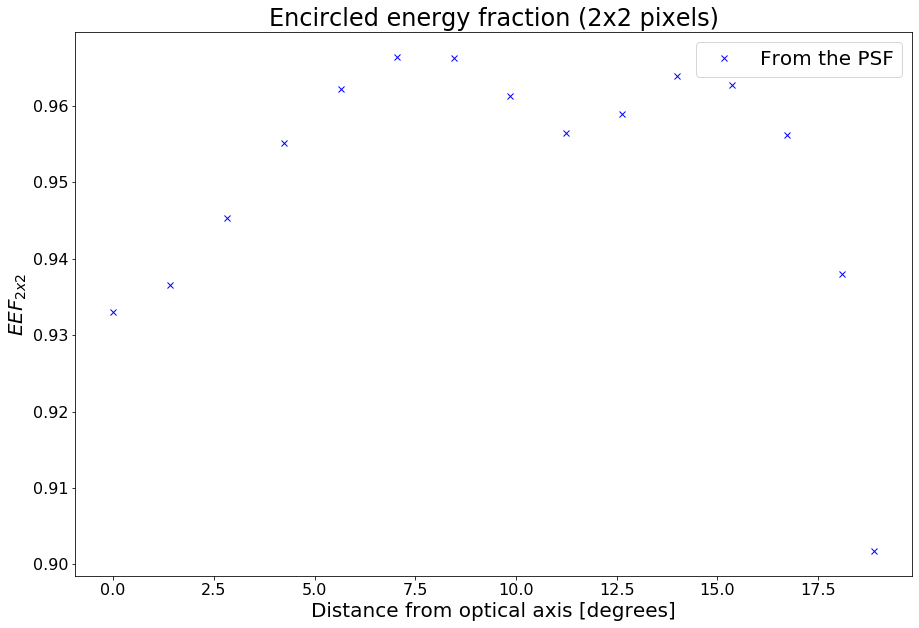

In [5]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction2by2, "bx", label = "From the PSF")

########
# Layout
########

plt.title("Encircled energy fraction (2x2 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{2x2}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

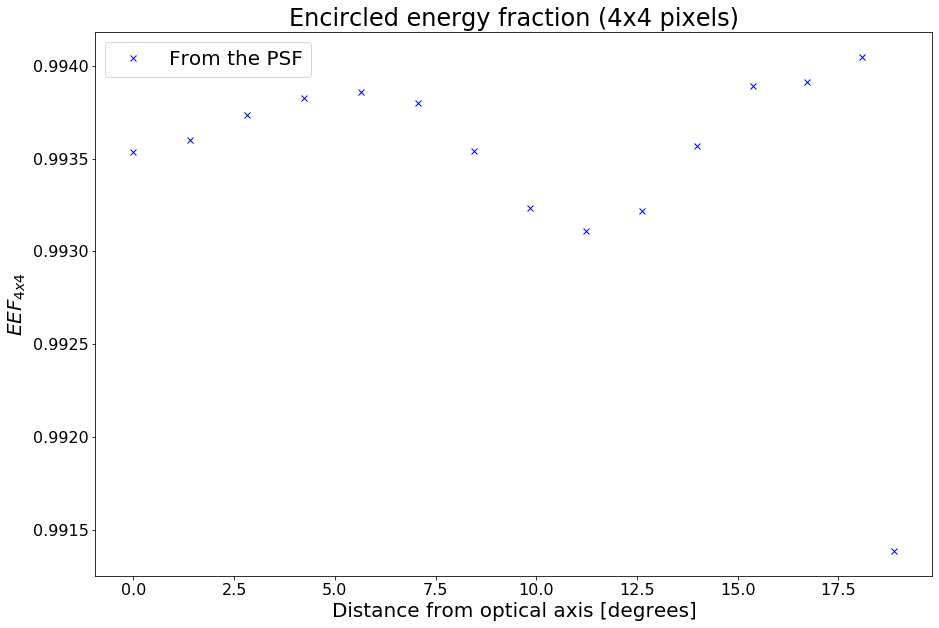

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction4by4, "bx", label = "From the PSF")

########
# Layout
########

plt.title("Encircled energy fraction (4x4 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{4x4}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

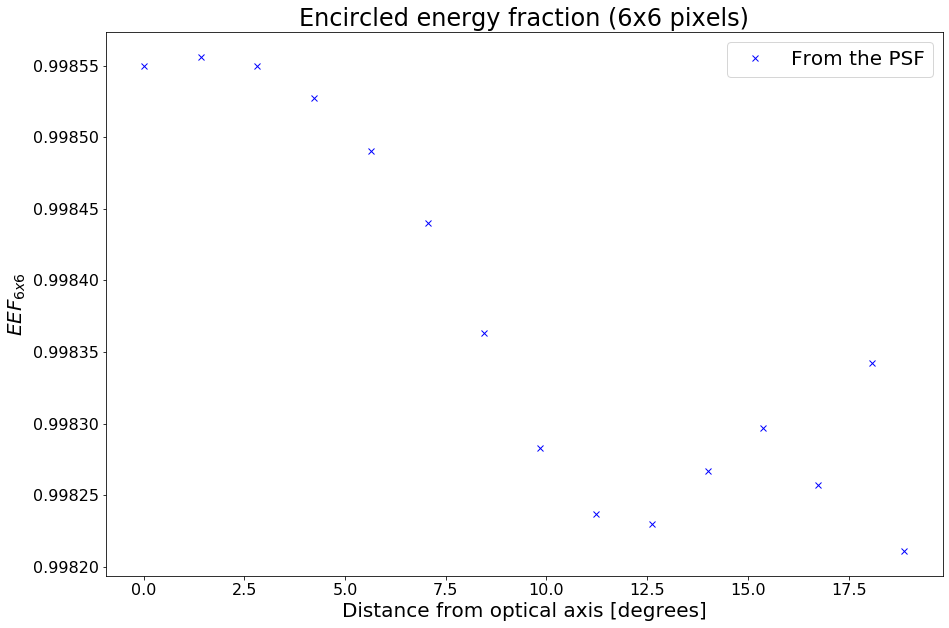

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(distances, encircledEnergyFraction6by6, "bx", label = "From the PSF")

########
# Layout
########

plt.title("Encircled energy fraction (6x6 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{6x6}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

In [8]:
dim = 8
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
sim["SubField/SubPixels"] = numSubPixels

sim["PSF/Model"] = "MappedFromFileSymmetrical"

In [9]:
# # Background

# # Make sure no sources are located in the sub-field

# sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# background = sim.run(removeOutputFile = True).getSubPixelImage(0)

In [10]:
sim["ObservingParameters/NumExposures"] = 1
sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

In [11]:
sim["Sky/SkyBackground"] = 0
magnitude = 12.5

In [12]:
positions = np.arange(dim, 4600, 100)
offset = 0.5

encircledEnergyFraction2by2_sim = np.array([])
encircledEnergyFraction4by4_sim = np.array([])
encircledEnergyFraction6by6_sim = np.array([])

for position in positions:
    
    sim["SubField/ZeroPointRow"] = position - dim // 2
    sim["SubField/ZeroPointColumn"] = position - dim // 2
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position + offset]), np.array([position + offset]), np.array([magnitude]), np.array([1]), starCatalogFilename)
    
    output = sim.run(removeOutputFile = True)
    subPixelImage = output.getSubPixelImage(0)

    startIndex = int(dim * numSubPixels / 2) - 1 * numSubPixels
    endIndex = startIndex + 2 * numSubPixels
    energy2by2 = np.sum(subPixelImage[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim * numSubPixels / 2) - 2 * numSubPixels
    endIndex = startIndex + 4 * numSubPixels
    energy4by4 = np.sum(subPixelImage[startIndex:endIndex, startIndex:endIndex])
    
    startIndex = int(dim * numSubPixels / 2) - 3 * numSubPixels
    endIndex = startIndex + 6 * numSubPixels
    energy6by6 = np.sum(subPixelImage[startIndex:endIndex, startIndex:endIndex])
    
    encircledEnergyFraction2by2_sim = np.append(encircledEnergyFraction2by2_sim, energy2by2)
    encircledEnergyFraction4by4_sim = np.append(encircledEnergyFraction4by4_sim, energy4by4)
    encircledEnergyFraction6by6_sim = np.append(encircledEnergyFraction6by6_sim, energy6by6)

In [13]:
# Convert the magnitude to flux (for the total flux)

fluxm0 = sim["ObservingParameters/Fluxm0"]
throughputBandWidth = sim["Camera/ThroughputBandwidth"]
transmissionEfficiency = sim["Telescope/TransmissionEfficiency/BOL"]
lightCollectingArea = sim["Telescope/LightCollectingArea"] * 1e-4

fluxFactor = fluxm0 * throughputBandWidth * transmissionEfficiency * lightCollectingArea

timeStep = sim["ObservingParameters/CycleTime"] - sim.getReadoutTime()[0]  # Exposure time [s]

totalFlux =  math.floor(fluxFactor * pow(10.0, -0.4 * magnitude) * timeStep)

In [14]:
halfwayPoints = (distances[1:] + distances[:-1]) / 2.0

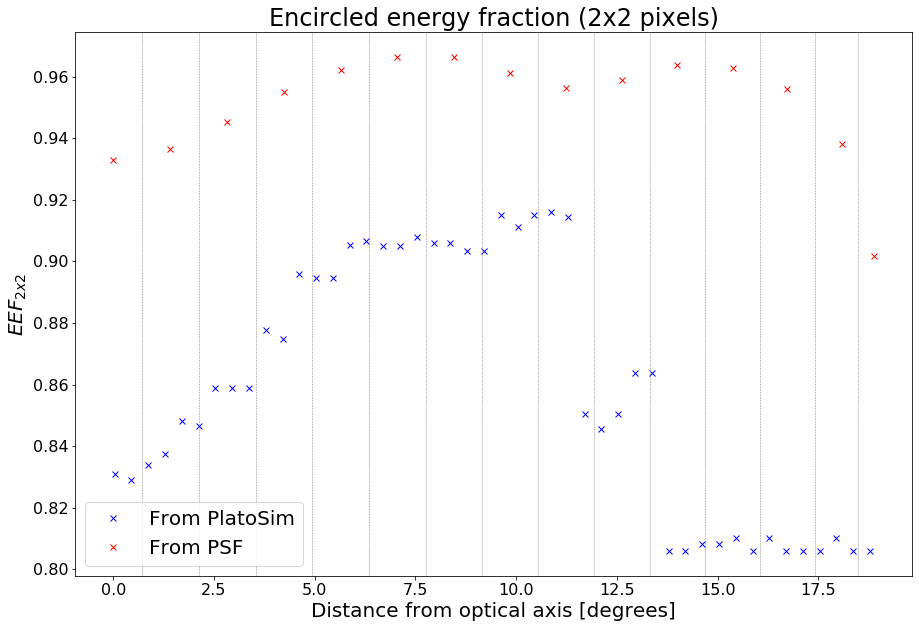

In [15]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction2by2_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction2by2, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (2x2 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{2x2}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

for halfwayPoint in halfwayPoints:
    
    plt.axvline(x=halfwayPoint, color="gray", linestyle="dashed", linewidth=0.5)

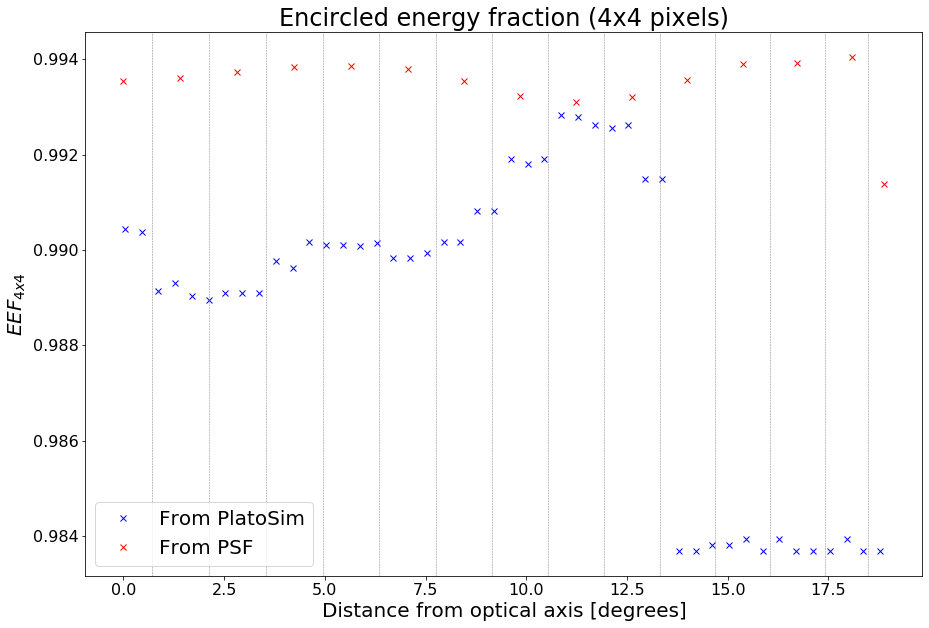

In [16]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction4by4_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction4by4, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (4x4 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{4x4}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

for halfwayPoint in halfwayPoints:
    
    plt.axvline(x=halfwayPoint, color="gray", linestyle="dashed", linewidth=0.5)

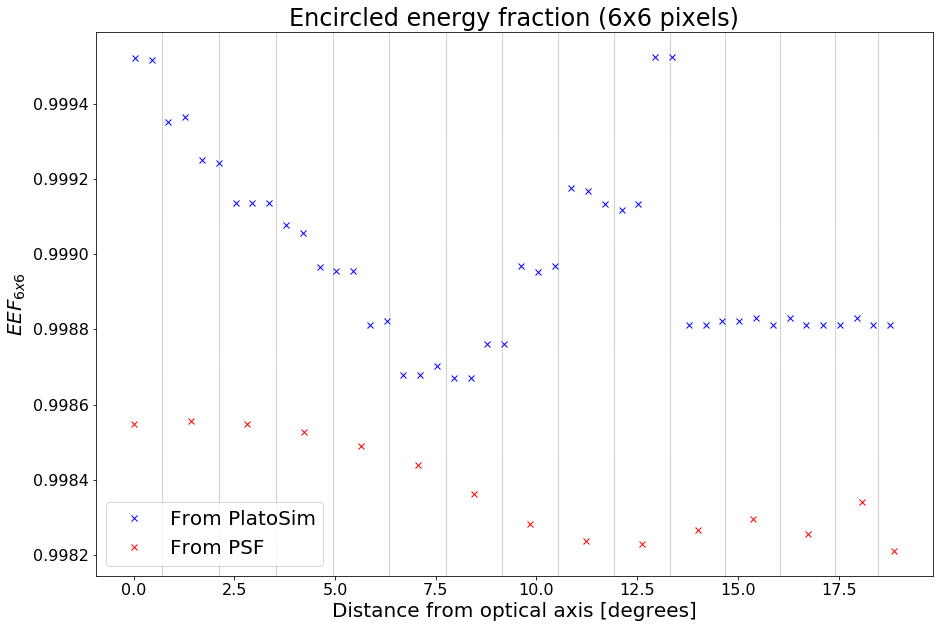

In [17]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions * plateScaleArcsec / constants.degree * constants.arcsec, encircledEnergyFraction6by6_sim / totalFlux, "bx", label="From PlatoSim")
plt.plot(distances, encircledEnergyFraction6by6, "rx", label="From PSF")



########
# Layout
########

plt.title("Encircled energy fraction (6x6 pixels)", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$EEF_{6x6}$", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
# plt.xlim([0, fovDegrees])

for halfwayPoint in halfwayPoints:
    
    plt.axvline(x=halfwayPoint, color="gray", linestyle="dashed", linewidth=0.5)

**Remarks**
* PSF = noiseless
* PSF = normalised (i.e. as if there is no flux loss at the edges)